# 🦎 MISSION 5: OPERATION CHAMELEON HUNTER
### "Mastering Vector Distance & Boolean Masking"

**TUJUAN:** Menggabungkan konsep **Aljabar Linear (Vektor)** dan **Pengolahan Gambar (Matriks)**. Anda akan membuat algoritma "Color Segmentation" sederhana untuk mendeteksi objek berdasarkan warnanya dan mengubah latar belakang menjadi hitam-putih.

---

### 🧠 KONSEP MATEMATIKA: WARNA SEBAGAI RUANG 3D

Di mata komputer, warna bukanlah sensasi visual, melainkan **Koordinat** di dalam ruang 3-Dimensi (RGB). Mencari warna yang "mirip" sama artinya dengan mengukur **Jarak Lurus** antara dua titik di ruang tersebut.

**1. Pixel sebagai Vektor:**
Setiap pixel dalam gambar adalah vektor $\vec{p}$ dengan 3 komponen (koordinat):
$$\vec{p} = [R, G, B]$$

**2. Jarak Euclidean (Inti dari Norm):**
Untuk mengetahui seberapa dekat sebuah pixel $\vec{p}$ dengan warna target $\vec{t}$, kita menggunakan rumus jarak Euclidean. Dalam aljabar linear, jarak ini disebut sebagai **Norm** (panjang vektor selisih).

Rumus Jarak $d(\vec{p}, \vec{t})$:
$$d = \|\vec{p} - \vec{t}\|$$

Jika dibedah, rumusnya adalah akar dari jumlah kuadrat selisih komponennya (Pythagoras 3D):
$$d = \sqrt{(R_p - R_t)^2 + (G_p - G_t)^2 + (B_p - B_t)^2}$$

* **Jarak $\approx$ 0:** Pixel sangat dekat dengan Target (Warna Mirip).
* **Jarak Besar:** Pixel jauh dari Target (Warna Beda).

**3. Implementasi NumPy (Axis & Dimension):**
Gambar adalah tumpukan 3 lapis (Tensor).
* Shape: `(Tinggi, Lebar, 3)`.
* Untuk menghitung jarak, kita harus menjumlahkan selisih $R^2 + G^2 + B^2$.
* Karena R, G, B ada di dimensi terakhir (index 2), kita menggunakan `np.sum(..., axis=2)` untuk "menggeprek" 3 lapis warna menjadi 1 lapis jarak.

**4. Boolean Masking (Logika Seleksi):**
Kita menggunakan *Threshold* (ambang batas toleransi) untuk memfilter pixel.
$$\text{Mask} = \begin{cases} \text{True (Simpan Warna)}, & \text{jika } d < \text{Threshold} \\ \text{False (Buang Warna)}, & \text{jika } d \ge \text{Threshold} \end{cases}$$

---

### 📝 INSTRUKSI TUGAS

**1. Persiapan Data:**
* Cari gambar dengan objek berwarna mencolok (misal: Bunga Merah, Jeruk Kuning).
* Load gambar ke NumPy array.
* **PENTING:** Cek tipe data. Jika integer (0-255), targetmu harus skala 0-255. Jika float (0-1), targetmu harus skala 0-1.

**2. Tentukan Target (The Hunter):**
* Pilih warna target yang ingin dideteksi.
* Contoh Kuning (Float): `target = np.array([1.0, 1.0, 0.0])`.

**3. Hitung Jarak (Vector Operation):**
* Lakukan pengurangan: `selisih = img - target`.
* **Cara Manual (Untuk Belajar):**
    1.  Kuadratkan: `selisih ** 2`.
    2.  Jumlahkan Channel: `np.sum(..., axis=2)`.
    3.  Akar: `np.sqrt(...)`.
* **Cara Pro (Jalan Pintas):**
    * Gunakan `np.linalg.norm(selisih, axis=2)`.

**4. Buat Masker (Thresholding):**
* Tentukan `threshold` (misal: 0.5 untuk float atau 80 untuk int).
* Buat array Boolean: `mask = jarak < threshold`.

**5. Segmentasi (Layering):**
* **Opsi A (Black Background):**
    * Gunakan Boolean Indexing: `img[~mask] = 0`. (Simbol `~` artinya NOT/Kebalikan).
* **Opsi B (Grayscale Background):**
    * Buat versi Grayscale gambar asli.
    * Tumpuk masker menjadi 3D: `np.stack((mask,)*3, axis=2)`.
    * Gabungkan dengan `np.where(mask_3d, img_asli, img_gray)`.

**6. Visualisasi:**
* Tampilkan gambar Asli dan Hasil Segmentasi berdampingan untuk melihat akurasi deteksimu.

> **Tips Engineer:** Mulailah dengan `threshold` ketat (kecil), lalu perbesar perlahan sampai seluruh objek target tertangkap sempurna.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from main import show_image

(300, 618, 3)
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]


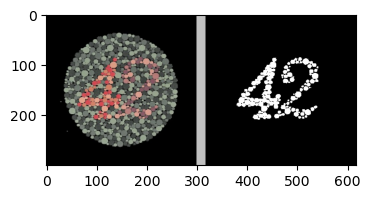

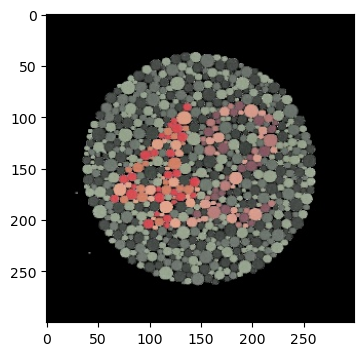

(616, 910, 3)
[[[0.21960784 0.34901962 0.00784314]
  [0.21960784 0.34901962 0.00784314]
  [0.21960784 0.34901962 0.00784314]
  ...
  [0.23137255 0.3764706  0.        ]
  [0.23137255 0.3764706  0.00392157]
  [0.23529412 0.38039216 0.00784314]]

 [[0.21960784 0.34901962 0.00784314]
  [0.22352941 0.3529412  0.01176471]
  [0.22352941 0.3529412  0.01176471]
  ...
  [0.23137255 0.3764706  0.        ]
  [0.23137255 0.3764706  0.00392157]
  [0.23529412 0.38039216 0.00784314]]

 [[0.22352941 0.3529412  0.01176471]
  [0.22745098 0.35686275 0.01568628]
  [0.22745098 0.35686275 0.01568628]
  ...
  [0.23529412 0.38039216 0.00392157]
  [0.23529412 0.38039216 0.00784314]
  [0.23529412 0.38039216 0.00784314]]

 ...

 [[0.32941177 0.46666667 0.07450981]
  [0.25882354 0.39215687 0.01960784]
  [0.16862746 0.3019608  0.        ]
  ...
  [0.16470589 0.32156864 0.28627452]
  [0.16078432 0.31764707 0.3137255 ]
  [0.16078432 0.3254902  0.32156864]]

 [[0.36078432 0.49803922 0.09019608]
  [0.2784314  0.4117647

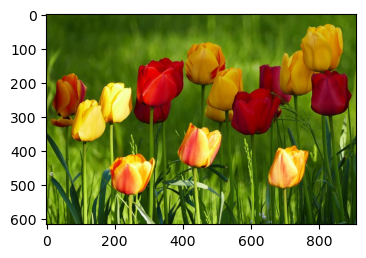

In [24]:
img_1 = plt.imread("c1_segment.png").copy()
img_2 = plt.imread("c2_segment.png").copy()

print(img_1.shape)
print(img_1)
show_image(img_1)
img_1 = img_1[:, :300]
show_image(img_1)

print(img_2.shape)
print(img_2)
show_image(img_2)

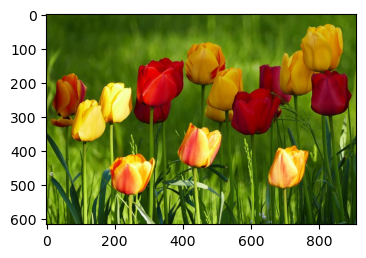

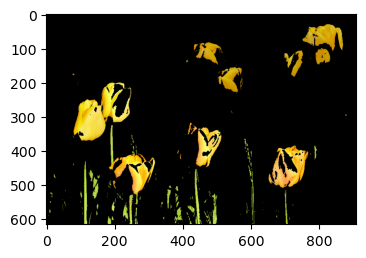

In [41]:
# cara manual menghitung euclid distance atau norm (panjang vector), menyesuaikan rumus euclid
img = img_2.copy()
target = np.array([1., 1., 0.])

jumlah_selisih = np.sum(((img - target)**2), axis=2)
jarak = np.sqrt(jumlah_selisih)

arr_bool_2d = jarak < 0.50
arr_bool_3d = np.stack((arr_bool_2d, arr_bool_2d, arr_bool_2d), axis=2)

final = np.where(arr_bool_3d, img, 0)

show_image(img)
show_image(final)

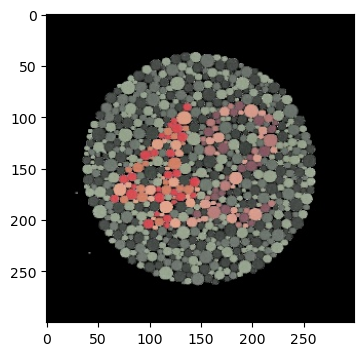

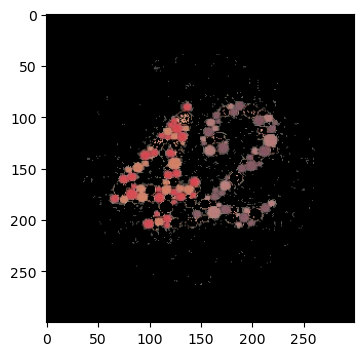

In [51]:
# cara yang lebih simple, menghitung euclid distance dengan np.linalg.norm
# norm = panjang vector, jadi ketika kita sudah tau selisih (jarak), bisa langsung dihitung panjangnya
img = img_1.copy()
show_image(img)

target = np.array([1., 0, 0])
selisih = img - target

jarak = np.linalg.norm(selisih, axis=2)
batas = 0.82

hasil = jarak < batas

# ini bagian keren-nya
# numpy bisa langsung melakukan pencarian di posisi true sesuai arr hasil yang berisi bool
# kemudian mengganti nya menjadi 0
# walaupun hasil itu arr 2d (x, y) sedangkan img itu arr 3d (x, y, z)
# numpy secara langsung mengganti semua value di posisi (x, y) di semua channel z
img[~hasil] = 0

show_image(img)

# plt bisa simpan img coy
plt.imsave("img.png", img)